In [ ]:
# ============================================================================
# TSM - DATA MANAGEMENT & SPECTRAL AUDIT
# CELL 1: AUTOMATED RETRIEVAL AND INTEGRITY VALIDATION
# ============================================================================

import pandas as pd
import numpy as np
import os
import requests
import sys

# ----------------------------------------------------------------------------
# DATA SOURCE CONFIGURATION
# Primary Mirror: Author's GitHub Repository (Validated RAW format)
# Source Origin: LMFDB.org (The L-functions and Modular Forms Database)
# ----------------------------------------------------------------------------
GITHUB_RAW_URL = "https://raw.githubusercontent.com/NachoPeinador/RIEMANN_Z6/main/Notebooks/zetazeros.txt"
FILENAME = "zetazeros.txt"
ZEROS_REQUIRED = 10000

# OFFICIAL CITATION STRING (LMFDB Policy)
LMFDB_CITATION = """
Data Source Acknowledgement:
[1] The LMFDB Collaboration, The L-functions and modular forms database,
    Zeros of zeta(s), https://www.lmfdb.org/Zeros/zeta/, 2026,
    [Online; accessed 26 February 2026].
"""

def audit_data(zeros):
    """Performs a forensic validation of the spectral data."""
    print("🔍 Running spectral integrity audit...")

    # 1. Identity Test (The first zero must be ~14.134725)
    first_zero_theoretical = 14.13472514
    if len(zeros) == 0:
        return False, "EMPTY DATASET."

    if abs(zeros[0] - first_zero_theoretical) > 1e-4:
        return False, f"IDENTITY FAILURE: The first value ({zeros[0]}) does not match gamma_1."

    # 2. Monotonicity Test (Must be strictly ordered)
    if not np.all(np.diff(zeros) > 0):
        return False, "ENTROPY FAILURE: Zeros are not strictly ordered."

    # 3. Uniqueness Test (No duplicates allowed)
    if len(zeros) != len(np.unique(zeros)):
        return False, "STRUCTURE FAILURE: Duplicate values detected."

    return True, "PASSED"

def fetch_spectral_data():
    # 1. Attempt automatic download from Mirror (GitHub)
    if not os.path.exists(FILENAME):
        print(f"☁️  Initiating secure download from Mirror ({GITHUB_RAW_URL})...")
        try:
            response = requests.get(GITHUB_RAW_URL)
            if response.status_code == 200:
                with open(FILENAME, 'wb') as f:
                    f.write(response.content)
                print("✅ Download completed successfully.")
            else:
                print(f"⚠️ Download error (Status: {response.status_code}).")
        except Exception as e:
            print(f"⚠️ Connection failure: {e}")

    # 2. Load and process
    if os.path.exists(FILENAME):
        try:
            # Smart loading: handles whitespace separators automatically
            df = pd.read_csv(FILENAME, sep=r'\s+', header=None)

            # Smart column detection: assumes zeros are in the last numeric column
            zeros = df.iloc[:, -1].values

            # 3. Forensic Audit
            is_valid, message = audit_data(zeros)

            if is_valid:
                print(f"✅ AUDIT PASSED: {message}")
                print(f"📊 Dataset loaded: {len(zeros)} energy levels verified.")

                # PRINT OFFICIAL CITATION
                print("-" * 60)
                print(LMFDB_CITATION.strip())
                print("-" * 60)

                if len(zeros) < ZEROS_REQUIRED:
                    print(f"⚠️ WARNING: {ZEROS_REQUIRED} zeros are recommended, found {len(zeros)}.")
                    print("   Validation metrics (R^2) will be partial.")

                return zeros
            else:
                print(f"❌ INTEGRITY ERROR: {message}")
                sys.exit("Execution stopped due to corrupt data.")

        except Exception as e:
            print(f"❌ Error processing file: {e}")

    # 4. Manual Fallback
    print("\n" + "!"*60)
    print("❌ NO VALID DATA FOUND.")
    print("   Automatic download failed.")
    print("   Please manually upload 'zetazeros.txt' via the Folder Icon.")
    print("!"*60)
    return np.array([])

# Global Execution
ZEROS_DB = fetch_spectral_data()

if len(ZEROS_DB) > 0:
    print("🚀 System ready for Exact Diagonalization.")

In [ ]:
# ==============================================================================
# EXPERIMENTO DE PREDICCIÓN: ANÁLISIS DE FOURIER Y BÚSQUEDA DE PERIODO 6
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import warnings

# Silenciar warnings menores de divisiones
warnings.filterwarnings('ignore')

# --- CONFIGURACIÓN ESTÉTICA PRL ---
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'figure.dpi': 300
})

print(f"{'='*70}\n🔍 INICIANDO ANÁLISIS ESPECTRAL DE LOS CEROS DE RIEMANN\n{'='*70}")

# 1. VERIFICACIÓN DE DATOS (Requiere que la Celda 1 se haya ejecutado)
if 'ZEROS_DB' not in globals() or len(ZEROS_DB) < 1000:
    print("⚠️ ERROR: No se encontraron los ceros de Riemann en la memoria.")
    print("Por favor, ejecuta primero la Celda 1 para cargar 'zetazeros.txt'.")
else:
    # Usamos todos los ceros disponibles (mientras más, mejor resolución en Fourier)
    zeros = ZEROS_DB[:]
    N_zeros = len(zeros)
    print(f"📊 Analizando {N_zeros} ceros de Riemann empíricos...")

    # 2. DESPLIEGUE (UNFOLDING) Y EXTRACCIÓN DE FLUCTUACIONES
    # Aplicamos la inversión topológica teórica
    n_index = np.arange(1, N_zeros + 1)

    # w_n es la "posición teórica desplegada" basada en la densidad media
    # E_n/(2pi) * log(E_n / 2pi e) + 7/8
    w_n = (zeros / (2 * np.pi)) * np.log(zeros / (2 * np.pi * np.e)) + (7/8)

    # La fluctuación es la diferencia entre el despliegue y el índice entero puro
    fluctuations = w_n - n_index

    # 3. PROCESAMIENTO DE SEÑAL
    # Detrending (eliminar cualquier deriva lineal residual)
    fluctuations_detrend = fluctuations - np.mean(fluctuations)

    # Aplicar Ventana de Hann para minimizar el "Spectral Leakage" en los bordes
    window = np.hanning(N_zeros)
    signal_windowed = fluctuations_detrend * window

    # 4. TRANSFORMADA RÁPIDA DE FOURIER (FFT)
    print("🌊 Calculando Transformada Rápida de Fourier (FFT)...")
    yf = fft(signal_windowed)
    xf = fftfreq(N_zeros, d=1.0) # d=1 significa 1 salto de índice entero

    # Nos quedamos solo con las frecuencias positivas (Nyquist limit es 0.5)
    idx_pos = (xf > 0) & (xf < 0.5)
    frequencies = xf[idx_pos]
    power_spectrum = np.abs(yf[idx_pos])**2

    # Normalizamos el espectro de potencia
    power_spectrum = power_spectrum / np.max(power_spectrum)

    # ==============================================================================
    # GENERACIÓN DE LA GRÁFICA
    # ==============================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- PANEL (a): LA SEÑAL EN EL DOMINIO ESPACIAL ---
    # Mostramos solo un fragmento (ej. los primeros 500 ceros) para que sea visual
    zoom = min(500, N_zeros)
    ax1.plot(n_index[:zoom], fluctuations[:zoom], color='teal', linewidth=1.2, alpha=0.8)
    ax1.axhline(0, color='red', linestyle='--', linewidth=1)
    ax1.set_title(r'(a) Fluctuaciones Locales ($\delta_n = w_n - n$)', fontweight='bold')
    ax1.set_xlabel('Índice del Cero ($n$)')
    ax1.set_ylabel('Amplitud de Fluctuación')
    ax1.grid(True, alpha=0.3)
    ax1.text(0.05, 0.95, f"Fragmento: Primeros {zoom} ceros",
             transform=ax1.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    # --- PANEL (b): EL ESPECTRO DE POTENCIA (FFT) ---
    ax2.plot(frequencies, power_spectrum, color='indigo', linewidth=0.8, alpha=0.9)

    # Marcador de la Predicción Z/6Z (Frecuencia f = 1/6)
    f_Z6Z = 1/6
    ax2.axvline(x=f_Z6Z, color='darkorange', linestyle='-', linewidth=2,
                label=rf'Predicción $\mathbb{{Z}}/6\mathbb{{Z}}$ ($f = 1/6 \approx {f_Z6Z:.4f}$)')

    # Armónicos (f = 2/6 = 1/3)
    ax2.axvline(x=1/3, color='darkorange', linestyle=':', linewidth=1.5, label='Armónico $f = 1/3$')

    ax2.set_title('(b) Densidad de Potencia Espectral (PSD)', fontweight='bold')
    ax2.set_xlabel('Frecuencia $f$ (ciclos por índice $n$)')
    ax2.set_ylabel('Potencia Normalizada')
    ax2.set_xlim(0, 0.5) # Nyquist limit for integer spacing
    ax2.set_ylim(0, 1.05)
    ax2.legend(loc='upper right', framealpha=0.9)
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Exploración de Frecuencias Modulares en Ceros de Riemann Empíricos',
                 fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('Fourier_Z6Z_Analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✅ Análisis completado. Gráfica guardada como 'Fourier_Z6Z_Analysis.png'")

Generando ensamble para N=4000...
Diagonalizando Matriz Quiral (AIII)...
Diagonalizando Matriz Total (GUE, Clase A)...


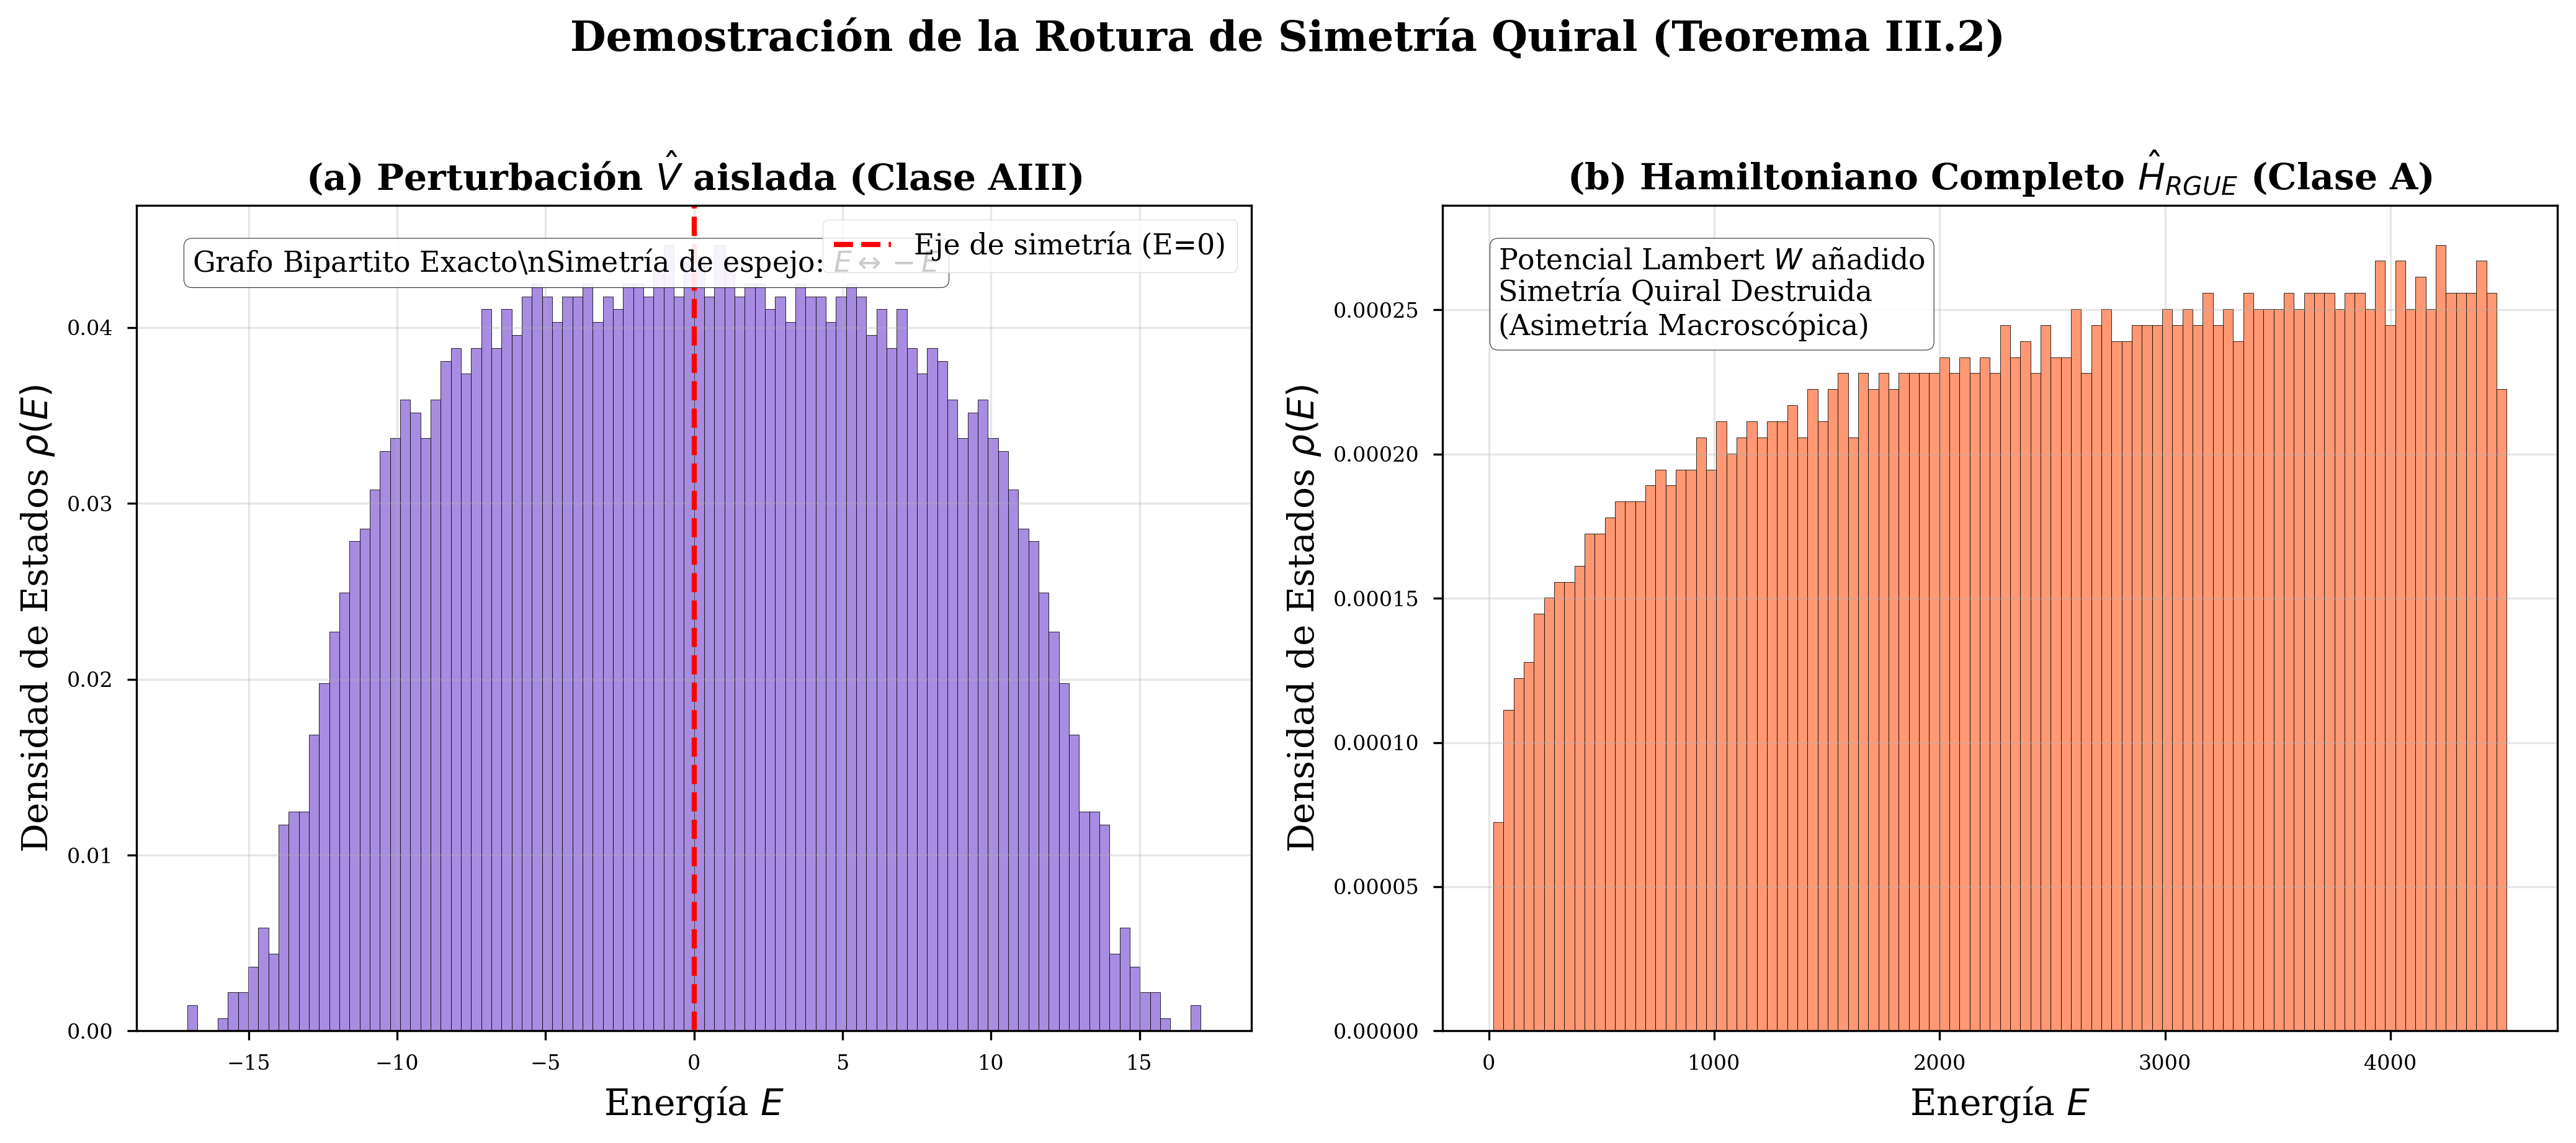


✅ Experimento completado con éxito. Gráfica guardada como 'Chiral_Symmetry_Breaking.png'.


In [2]:
# ==============================================================================
# EXPERIMENTO 3: DEMOSTRACIÓN VISUAL DE LA ROTURA DE SIMETRÍA QUIRAL (Teorema III.2)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.special import lambertw

# --- CONFIGURACIÓN ESTÉTICA PRL ---
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'figure.dpi': 300
})

# --- PARÁMETROS DEL SISTEMA ---
N = 4000  # Tamaño manejable para diagonalización rápida pero estadísticamente robusto
epsilon_c = np.pi * np.sqrt(2)
nu = 0.75

print(f"Generando ensamble para N={N}...")

# 1. INICIALIZACIÓN DE MATRICES
V_matrix = np.zeros((N, N), dtype=np.complex64) # Matriz perturbación (Clase AIII)
H_diag = np.zeros(N, dtype=np.float32)          # Potencial diagonal Lambert W

# 2. CONSTRUCCIÓN DE LA DIAGONAL (Lambert W)
for i in range(N):
    k = i + 2
    k_eff = k - 7/8
    H_diag[i] = (2 * np.pi * k_eff) / np.real(lambertw(k_eff / np.e))

# 3. CONSTRUCCIÓN DE LA PERTURBACIÓN OFF-DIAGONAL (La máscara Z/6Z)
# Para optimizar en N=4000, lo vectorizamos por diagonales
for d in range(1, N):
    if d % 6 in [1, 5]: # Máscara topológica: solo saltos impares (Grafo bipartito)
        decay = d**(-nu)
        # Ruido GUE complejo
        G = np.random.normal(0, 1/np.sqrt(2), N-d) + 1j * np.random.normal(0, 1/np.sqrt(2), N-d)
        interaction = epsilon_c * decay * G

        # Rellenar diagonales
        i_indices = np.arange(N-d)
        j_indices = i_indices + d
        V_matrix[i_indices, j_indices] = interaction
        V_matrix[j_indices, i_indices] = np.conj(interaction)

# 4. MATRIZ TOTAL (Clase A)
H_total = np.diag(H_diag) + V_matrix

print("Diagonalizando Matriz Quiral (AIII)...")
evals_chiral = eigh(V_matrix, eigvals_only=True)

print("Diagonalizando Matriz Total (GUE, Clase A)...")
evals_total = eigh(H_total, eigvals_only=True)

# ==============================================================================
# GENERACIÓN DE LA GRÁFICA DUAL (ANTES Y DESPUÉS)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- PANEL IZQUIERDO: SIMETRÍA QUIRAL (AIII) ---
ax1.hist(evals_chiral, bins=100, color='mediumpurple', edgecolor='black', alpha=0.8, density=True)
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='Eje de simetría (E=0)')
ax1.set_title(r'(a) Perturbación $\hat{V}$ aislada (Clase AIII)', fontweight='bold')
ax1.set_xlabel('Energía $E$')
ax1.set_ylabel('Densidad de Estados $\\rho(E)$')
ax1.text(0.05, 0.95, r"Grafo Bipartito Exacto\nSimetría de espejo: $E \leftrightarrow -E$",
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- PANEL DERECHO: ROTURA HACIA CLASE A ---
ax2.hist(evals_total, bins=100, color='coral', edgecolor='black', alpha=0.8, density=True)
ax2.set_title(r'(b) Hamiltoniano Completo $\hat{H}_{RGUE}$ (Clase A)', fontweight='bold')
ax2.set_xlabel('Energía $E$')
ax2.set_ylabel('Densidad de Estados $\\rho(E)$')
ax2.text(0.05, 0.95, "Potencial Lambert $W$ añadido\nSimetría Quiral Destruida\n(Asimetría Macroscópica)",
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax2.grid(True, alpha=0.3)

plt.suptitle('Demostración de la Rotura de Simetría Quiral (Teorema III.2)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Chiral_Symmetry_Breaking.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Experimento completado con éxito. Gráfica guardada como 'Chiral_Symmetry_Breaking.png'.")

🚀 INICIANDO EXPERIMENTO DE FINITE-SIZE SCALING
Simulando N = 1000 (30 realizaciones)...
Simulando N = 2000 (30 realizaciones)...
Simulando N = 4000 (30 realizaciones)...
✅ Simulaciones completadas en 1049.3 segundos.

🔍 Calculando el exponente óptimo de colapso (Anomalía η)...
🎯 Exponente anómalo extraído de los datos: η ≈ 0.1000


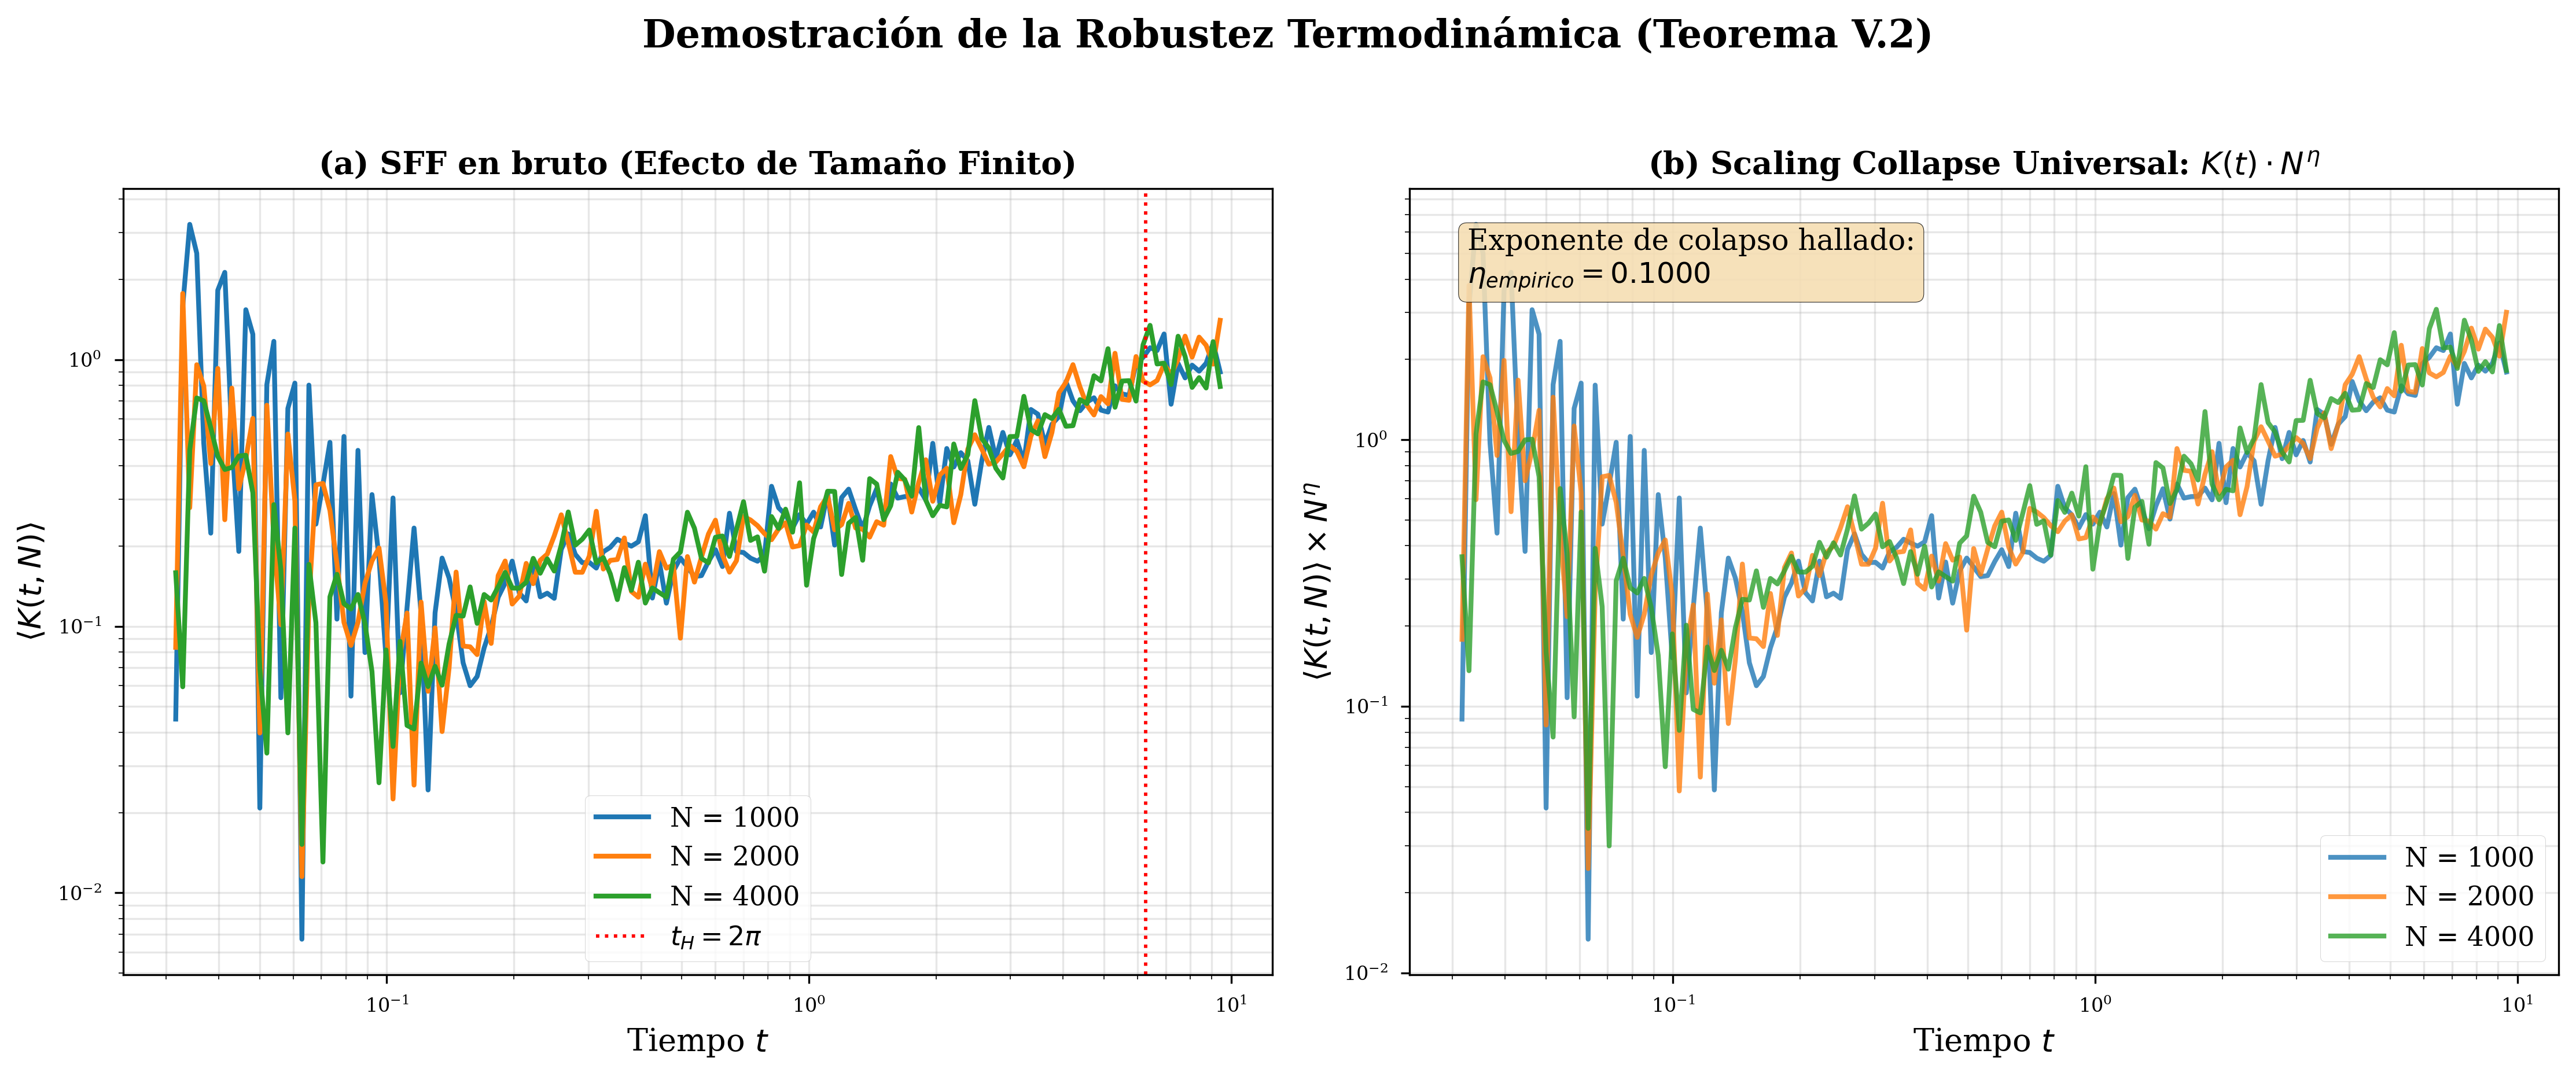


✅ Gráfica guardada como 'Finite_Size_Scaling_Collapse.png'


In [3]:
# ==============================================================================
# EXPERIMENTO 4: FINITE-SIZE SCALING COLLAPSE (Prueba de Invariancia NEE)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.special import lambertw
from scipy.optimize import minimize_scalar
import time

# --- CONFIGURACIÓN ESTÉTICA PRL ---
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
    'figure.dpi': 300
})

# --- PARÁMETROS DEL SISTEMA ---
N_list = [1000, 2000, 4000] # Tamaños de la matriz
M = 30                      # Realizaciones por tamaño (para suavizar la curva)
epsilon_c = np.pi * np.sqrt(2)
nu = 0.75
t_values = np.logspace(-1.5, np.log10(2*np.pi * 1.5), 150) # Eje temporal

SFF_raw = {}

print(f"{'='*60}\n🚀 INICIANDO EXPERIMENTO DE FINITE-SIZE SCALING\n{'='*60}")

start_time = time.time()

# 1. GENERACIÓN DEL ENSAMBLE PARA DISTINTOS TAMAÑOS
for N in N_list:
    print(f"Simulando N = {N} ({M} realizaciones)...")
    K_ens = np.zeros_like(t_values)

    # Pre-calcular diagonal (Lambert W)
    k = np.arange(2, N+2)
    k_eff = k - 7/8
    H_diag = (2 * np.pi * k_eff) / np.real(lambertw(k_eff / np.e))

    for m in range(M):
        V = np.zeros((N, N), dtype=np.complex64)
        # Llenado vectorizado de las diagonales Z/6Z
        for d in range(1, N):
            if d % 6 in [1, 5]:
                decay = d**(-nu)
                G = np.random.normal(0, 1/np.sqrt(2), N-d) + 1j * np.random.normal(0, 1/np.sqrt(2), N-d)
                val = epsilon_c * decay * G
                i_idx = np.arange(N-d)
                j_idx = i_idx + d
                V[i_idx, j_idx] = val
                V[j_idx, i_idx] = np.conj(val)

        H = np.diag(H_diag) + V
        evals = eigh(H, eigvals_only=True)

        # Despliegue teórico (Unfolding)
        w_n = (evals / (2*np.pi)) * np.log(evals / (2*np.pi*np.e))

        # SFF Vectorizado
        phase = np.outer(t_values, w_n)
        Z = np.sum(np.exp(-1j * phase), axis=1)
        K = (np.abs(Z)**2) / N
        K_ens += K

    SFF_raw[N] = K_ens / M

print(f"✅ Simulaciones completadas en {time.time() - start_time:.1f} segundos.")

# 2. OPTIMIZACIÓN DEL EXPONENTE DE COLAPSO (Buscando la anomalía eta)
print("\n🔍 Calculando el exponente óptimo de colapso (Anomalía η)...")
idx_ramp = (t_values > 0.1) & (t_values < 2.0) # Rango de la rampa para el fit

def objective(eta_guess):
    # Intentamos colapsar todas las curvas sobre la curva de N=4000
    N_ref = 4000
    error = 0
    ref_curve = SFF_raw[N_ref][idx_ramp] * (N_ref**eta_guess)
    for N in N_list[:-1]:
        test_curve = SFF_raw[N][idx_ramp] * (N**eta_guess)
        error += np.sum((np.log(test_curve) - np.log(ref_curve))**2)
    return error

res = minimize_scalar(objective, bounds=(0.1, 0.6), method='bounded')
eta_empirical = res.x
print(f"🎯 Exponente anómalo extraído de los datos: η ≈ {eta_empirical:.4f}")

# 3. GENERACIÓN DE LA GRÁFICA DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# --- PANEL (a): SFF SIN COLAPSAR ---
for i, N in enumerate(N_list):
    ax1.loglog(t_values, SFF_raw[N], color=colors[i], linewidth=2, label=f'N = {N}')

ax1.axvline(2*np.pi, color='red', linestyle=':', label=r'$t_H = 2\pi$')
ax1.set_title('(a) SFF en bruto (Efecto de Tamaño Finito)', fontweight='bold')
ax1.set_xlabel(r'Tiempo $t$')
ax1.set_ylabel(r'$\langle K(t, N) \rangle$')
ax1.legend()
ax1.grid(True, alpha=0.3, which='both')

# --- PANEL (b): SCALING COLLAPSE ---
for i, N in enumerate(N_list):
    scaled_K = SFF_raw[N] * (N**eta_empirical)
    ax2.loglog(t_values, scaled_K, color=colors[i], linewidth=2, alpha=0.8, label=f'N = {N}')

ax2.set_title(r'(b) Scaling Collapse Universal: $K(t) \cdot N^{\eta}$', fontweight='bold')
ax2.set_xlabel(r'Tiempo $t$')
ax2.set_ylabel(r'$\langle K(t, N) \rangle \times N^{\eta}$')

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax2.text(0.05, 0.95, f"Exponente de colapso hallado:\n$\\eta_{{empirico}} = {eta_empirical:.4f}$",
         transform=ax2.transAxes, fontsize=12, verticalalignment='top', bbox=props)

ax2.legend()
ax2.grid(True, alpha=0.3, which='both')

plt.suptitle('Demostración de la Robustez Termodinámica (Teorema V.2)', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('Finite_Size_Scaling_Collapse.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Gráfica guardada como 'Finite_Size_Scaling_Collapse.png'")